# 트랜스포머로 만드는 대화형 챗봇

- 한국어 전처리를 통해 학습 데이터셋을 구축하였다.  
&rarr; 공백과 특수문자 처리, 토크나이징, 병렬데이터 구축의 과정이 적절히 진행되었다.  

- 트랜스포머 모델을 구현하여 한국어 챗봇 모델 학습을 정상적으로 진행하였다.  
&rarr; 구현한 트랜스포머 모델이 한국어 병렬 데이터 학습 시 안정적으로 수렴하였다.

- 한국어 입력문장에 대해 한국어로 답변하는 함수를 구현하였다.  
&rarr; 한국어 입력문장에 맥락에 맞는 한국어로 답변을 리턴하였다.  

# 0. 라이브러리 import 및 경로 세팅

In [1]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, TensorDataset, DataLoader
import torch.optim as optim
import torch.optim.lr_scheduler as lr_scheduler

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import re
from bs4 import BeautifulSoup
import sentencepiece as spm
from collections import Counter

import math
import os
import urllib.request
import zipfile
import random

In [2]:
# 재현성 확보를 위한 시드 고정 함수
def set_seed(seed=42):
    # 1. 파이썬 기본 난수 생성기 고정
    random.seed(seed)
    # 2. 넘파이 고정
    np.random.seed(seed)
    # 3. 파이토치 CPU 시드 고정
    torch.manual_seed(seed)
    # 4. 파이토치 GPU 시드 고정 (멀티 GPU 포함)
    torch.cuda.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    
    # 5. Cudnn(GPU 연산 라이브러리)의 결정론적 연산 설정
    # 연산 속도는 약간 느려질 수 있지만, 결과는 동일하게 나옴
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False
    
    # 6. 환경 변수 고정 (HuggingFace 등 일부 라이브러리 대응)
    os.environ['PYTHONHASHSEED'] = str(seed)
    
    print(f"Seed fixed to: {seed}")

# 실행
set_seed(42)

Seed fixed to: 42


In [3]:
DATA_PATH = "./trs_chatbot_data/"
MODEL_PATH = "./trs_chatbot_models/"

# 1. 데이터 전처리

## 1.1. 데이터 불러오기

In [4]:
DATA_NAME = "ChatbotData.csv"

In [5]:
raw_data = pd.read_csv(DATA_PATH + DATA_NAME)

print("Data Size:", len(raw_data))
raw_data.head()

Data Size: 11823


,Q,A,label
0,12시 땡!,하루가 또 가네요.,0
1,1지망 학교 떨어졌어,위로해 드립니다.,0
2,3박4일 놀러가고 싶다,여행은 언제나 좋죠.,0
3,3박4일 정도 놀러가고 싶다,여행은 언제나 좋죠.,0
4,PPL 심하네,눈살이 찌푸려지죠.,0


## 1.2. 데이터 분석 및 전처리

### 1.2.1. 중복 샘플 확인

In [6]:
print("전체 샘플 수: ", len(raw_data))
print('Q열에서 중복을 배제한 유일한 샘플의 수 :', raw_data['Q'].nunique())
print('A열에서 중복을 배제한 유일한 샘플의 수 :', raw_data['A'].nunique())

전체 샘플 수:  11823
Q열에서 중복을 배제한 유일한 샘플의 수 : 11662
A열에서 중복을 배제한 유일한 샘플의 수 : 7779


In [7]:
raw_data[raw_data.duplicated(subset=['Q'], keep=False)].sort_values(by='Q').head(6)

,Q,A,label
5316,2년 가량의 연애,안 좋은 기억보다 좋은 기억이 더 많았으면 좋겠네요.,1
8868,2년 가량의 연애,딱 잘 만났네요.,2
8901,가을 타나 봐.,외로운 옆구리를 채워보아요.,2
8902,가을 타나 봐.,혼자는 외로운 계절이죠.,2
5439,간단하게 사랑이라는건.,여러번 해도 어려워요.,1
5438,간단하게 사랑이라는건.,간단하지 않은 것.,1


In [8]:
raw_data[raw_data.duplicated(subset=['A'], keep=False)].sort_values(by='A').head(6)

,Q,A,label
1918,반배정 망했어,1년 힘내요.,0
1919,반배정부터 올해 끝났다.,1년 힘내요.,0
11522,짝녀가 좋아하는거 눈치 1도 못챔.,1은 알게 해야죠.,2
11390,짝남이 내가 좋아하는걸 1도 몰라.,1은 알게 해야죠.,2
5016,한복 맞출까 빌릴까,2번 이상 입을 일이 있으면 맞추세요.,0
5017,한복 빌려도 예쁠까,2번 이상 입을 일이 있으면 맞추세요.,0


In [9]:
print("Q, A 둘다 중복인 데이터: ", raw_data.duplicated(subset=['Q', 'A'], keep=False).sum())
raw_data[raw_data.duplicated(subset=['Q', 'A'], keep=False)].sort_values(by='Q').head(6)

Q, A 둘다 중복인 데이터:  146


,Q,A,label
152,결혼이나 하지 왜 자꾸 나한테 화 내냐구!,힘들겠네요.,0
5527,결혼이나 하지 왜 자꾸 나한테 화 내냐구!,힘들겠네요.,1
5537,고백하고 후회하면 어떡하지,후회는 후회를 낳을뿐이에요. 용기 내세요.,1
189,고백하고 후회하면 어떡하지,후회는 후회를 낳을뿐이에요. 용기 내세요.,0
226,공부는 내 체질이 아닌 것 같아,확신이 없나봐요.,0
5542,공부는 내 체질이 아닌 것 같아,확신이 없나봐요.,1


- 같은 상황(Q)에서 다양한 응답(A), 같은 응답(A)도 다른 상황(Q)에서 사용될 수 있음  
- 라벨이 달라서 Q,A 모두 중복인 경우가 있지만 146건으로 전체 11823건의 약 1% 정도라 제거하지 않기로 함  
&rarr; 중복을 제거하지 않고 사용

### 1.2.2. 결측치 확인

In [10]:
print(raw_data.isnull().sum())

Q        0
A        0
label    0
dtype: int64


In [11]:
# 결측치 있으면 제거
# raw_data.dropna(axis=0, inplace=True)
# print('전체 샘플수 :', (len(raw_data)))

&rarr; 결측치 없음

### 1.2.3. 전처리

In [12]:
# 데이터 전처리 함수
def preprocess_sentence(sentence):
    # 1. HTML 태그 제거 (BeautifulSoup 활용)
    sentence = BeautifulSoup(sentence, "lxml").text
    
    # 2. 괄호로 둘러싸인 문자열 제거 (부가 설명 제거)
    sentence = re.sub(r'\([^)]*\)', '', sentence)
    
    # 3. 특수문자 제거 (한글, 영어, 숫자, ?, !만 남기기)    
    sentence = re.sub(r"[^가-힣a-zA-Z0-9\s?!]", " ", sentence) 
    
    # 4. 의미 없는 자음/모음 반복 줄이기 (ㅋㅋㅋㅋㅋ -> ㅋㅋ)    
    sentence = re.sub(r'([ㄱ-ㅎㅏ-ㅣ])\1+', r'\1\1', sentence)
    
    # 5. 공백 정규화 (연속된 공백 하나로)
    sentence = re.sub(r'\s+', ' ', sentence).strip()    

    return sentence

In [13]:
# 전처리 후 별도 관리
preprocessed_df = pd.DataFrame()

preprocessed_df['Q'] = raw_data['Q'].apply(preprocess_sentence)
preprocessed_df['A'] = raw_data['A'].apply(preprocess_sentence)

In [14]:
# 중복 샘플 재확인
preprocessed_df.duplicated(subset=['Q', 'A'], keep=False).sum()

152

In [15]:
# 전처리 후 결측치 재확인
print(preprocessed_df.isnull().sum())

Q    0
A    0
dtype: int64


### 1.2.4. 문장 통계 확인

In [16]:
# corpus를 구성하는 각 문장의 길이를 재고, 
def check_sentence_stats(corpus):
   
    len_sentence = [len(sentence) for sentence in corpus]
    len_sentence = np.array(len_sentence)

    print('문장 길이 평균: ', np.mean(len_sentence))
    print('문장 길이 최대: ', np.max(len_sentence))
    print('문장 길이 최소: ', np.min(len_sentence))
    print('문장 길이 표준편차: ', np.std(len_sentence))
    print('문장 길이 중위수: ', np.median(len_sentence))

    max_len_sentence = np.max(len_sentence)

    sentence_length = np.zeros((max_len_sentence), dtype=int)

    for sen in corpus:
        sentence_length[len(sen)-1] += 1

    plt.bar(range(max_len_sentence), sentence_length, width=1.0)
    plt.title("Sentence Length Distribution")
    plt.show()

    return sentence_length

In [17]:
# 문장 길이에 해당하는 문장을 출력하는 함수
def check_sentence_with_length(raw_df, col_q, col_a, length):
    count = 0

    for sen in raw_df[col_q]:
        if len(sen) == length:
            print("Q: ", sen)
            ans = raw_df.loc[raw_df['Q'] == sen, col_a].values[0]
            print("A: ", ans)
            count += 1
            if count > 50: return

In [18]:
# 문장 길이 최소: 1인 경우 확인
check_sentence_with_length(preprocessed_df, 'Q', 'A', 1)

Q:  야
A:  네
Q:  음
A:  음
Q:  응
A:  네
Q:  헉
A:  놀랐나봐요
Q:  꿈
A:  꿈에 나왔나요
Q:  끝
A:  또 다른 시작
Q:  야
A:  네
Q:  왜
A:  궁금하네요
Q:  하
A:  힘내세요
Q:  후
A:  힘을 내세요
Q:  후
A:  힘을 내세요
Q:  휴
A:  아이구
Q:  흠
A:  마음이 복잡한가요


&rarr; 문장 길이가 1이어도 유용하므로 그대로 사용

문장 길이 평균:  12.67098029264992
문장 길이 최대:  56
문장 길이 최소:  1
문장 길이 표준편차:  6.047082694375173
문장 길이 중위수:  12.0


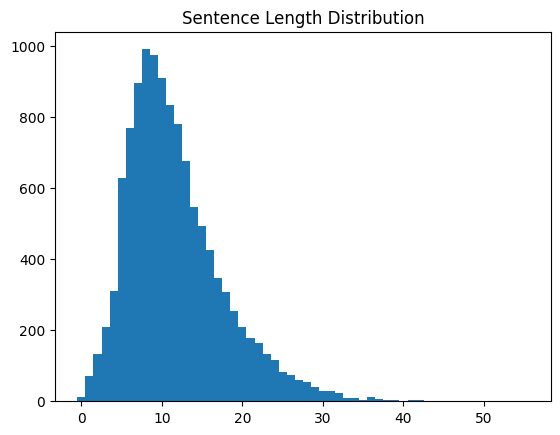

In [19]:
sentence_length = check_sentence_stats(preprocessed_df['Q'])

문장 길이 평균:  14.019622769178719
문장 길이 최대:  74
문장 길이 최소:  1
문장 길이 표준편차:  6.6308866931152055
문장 길이 중위수:  13.0


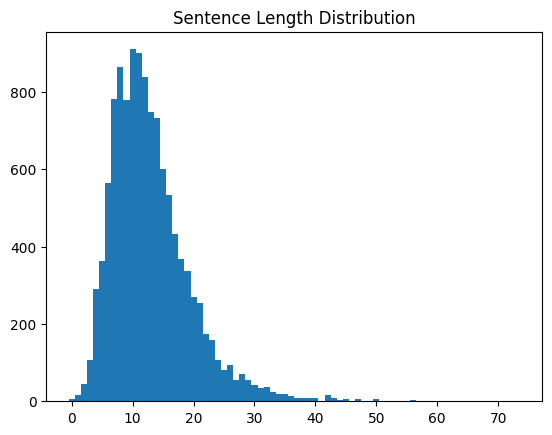

In [20]:
sentence_length = check_sentence_stats(preprocessed_df['A'])

&rarr; 데이터 개수가 적다고 판단하여 최대 길이 문장까지 사용하기로 함

In [21]:
# 여기서의 MAX_SEN_LEN은 토크나이저 학습을 위한 최대 문장 길이를 의미함
# Q: 56, A: 74인데 합쳐서 SentencePiece에 넣고 학습할거라 100으로 잡아줌

MAX_SEN_LEN = 100

## 1.3. SentencePiece 학습

### 1.3.1. SentencePiece 필요성 확인

In [22]:
# 등장 빈도수 낮은 단어를 어휘 사전에서 제외하기 위해 통계량 확인하는 함수
def check_rare_words_proportion(corpus, threshold):
    data_name = corpus.name
    corpus = corpus.tolist()
    # 단어 빈도수 계산
    word_counter = Counter()
    for text in corpus:
        word_counter.update(text.split())

    total_cnt = len(word_counter)  # 전체 단어 개수
    total_freq = sum(word_counter.values())  # 전체 단어 등장 횟수
    rare_cnt = sum(1 for count in word_counter.values() if count < threshold)  # 희귀 단어 개수
    rare_freq = sum(count for count in word_counter.values() if count < threshold)  # 희귀 단어 등장 횟수

    print("데이터: ", data_name)
    print('단어 집합(vocabulary)의 크기 :', total_cnt)
    print('등장 빈도가 %s번 이하인 희귀 단어의 수: %s'%(threshold - 1, rare_cnt))
    print('단어 집합에서 희귀 단어를 제외시킬 경우의 단어 집합의 크기 %s'%(total_cnt - rare_cnt))
    print("단어 집합에서 희귀 단어의 비율:", (rare_cnt / total_cnt)*100)
    print("전체 등장 빈도에서 희귀 단어 등장 빈도 비율:", (rare_freq / total_freq)*100)


In [23]:
check_rare_words_proportion(preprocessed_df['Q'], 5)

데이터:  Q
단어 집합(vocabulary)의 크기 : 13675
등장 빈도가 4번 이하인 희귀 단어의 수: 12305
단어 집합에서 희귀 단어를 제외시킬 경우의 단어 집합의 크기 1370
단어 집합에서 희귀 단어의 비율: 89.981718464351
전체 등장 빈도에서 희귀 단어 등장 빈도 비율: 40.71184443134944


&rarr; 한국어에는 어절 단위의 희귀 단어를 제외하는 것이 적절하지 않음을 확인

### 1.3.2. SentencePiece 학습

In [24]:
VOCAB_SIZE = 8000

In [25]:
# Q와 A를 모두 합쳐서 데이터로 사용
all_text = preprocessed_df['Q'].tolist() + preprocessed_df['A'].tolist()

In [26]:
# 파일로 저장 (SentencePiece는 파일 입력을 선호한다고 함)
with open(DATA_PATH + 'corpus_for_spm.txt', 'w', encoding='utf-8') as f:
    for line in all_text:
        f.write(line + '\n')

In [27]:
# SentencePiece 학습
spm.SentencePieceTrainer.train(
    input=DATA_PATH + 'corpus_for_spm.txt', 
    model_prefix=MODEL_PATH + 'chatbot_spm', 
    vocab_size=VOCAB_SIZE,      # 앞서 논의한 쫀득한 수치
    model_type='bpe',     # 혹은 'unigram'
    max_sentence_length=MAX_SEN_LEN,
    pad_id=0,             # 특수 토큰 지정
    unk_id=1,
    bos_id=2,
    eos_id=3
)

sentencepiece_trainer.cc(77) LOG(INFO) Starts training with : 
trainer_spec {
  input: ./trs_chatbot_data/corpus_for_spm.txt
  input_format: 
  model_prefix: ./trs_chatbot_models/chatbot_spm
  model_type: BPE
  vocab_size: 8000
  self_test_sample_size: 0
  character_coverage: 0.9995
  input_sentence_size: 0
  shuffle_input_sentence: 1
  seed_sentencepiece_size: 1000000
  shrinking_factor: 0.75
  max_sentence_length: 100
  num_threads: 16
  num_sub_iterations: 2
  max_sentencepiece_length: 16
  split_by_unicode_script: 1
  split_by_number: 1
  split_by_whitespace: 1
  split_digits: 0
  treat_whitespace_as_suffix: 0
  allow_whitespace_only_pieces: 0
  required_chars: 
  byte_fallback: 0
  vocabulary_output_piece_score: 1
  train_extremely_large_corpus: 0
  hard_vocab_limit: 1
  use_all_vocab: 0
  unk_id: 1
  bos_id: 2
  eos_id: 3
  pad_id: 0
  unk_piece: <unk>
  bos_piece: <s>
  eos_piece: </s>
  pad_piece: <pad>
  unk_surface:  ⁇ 
  enable_differential_privacy: 0
  differential_privacy_

- 토크나이저 결과 확인

In [28]:
# 모델 로드
sp_tokenizer = spm.SentencePieceProcessor()
sp_tokenizer.load(MODEL_PATH + 'chatbot_spm.model')

# 샘플 테스트
test_sentence = "사소한 일부터 시작해보세요 작은 곳에서 느끼는 행복은 생각보다 커요"
print("Tokenized:", sp_tokenizer.encode_as_pieces(test_sentence))

encoded = sp_tokenizer.encode(test_sentence, out_type=int)
# print("Encoded:", sp_tokenizer.encode_as_ids(test_sentence))
print("Encoded:", encoded)

decoded = sp_tokenizer.decode(encoded)
print("Decoded:", decoded)

Tokenized: ['▁사소한', '▁일부터', '▁시작해보세요', '▁작은', '▁곳에서', '▁느끼는', '▁행복은', '▁생각보다', '▁커', '요']
Encoded: [2801, 3829, 1829, 1321, 2776, 3373, 3099, 974, 423, 6924]
Decoded: 사소한 일부터 시작해보세요 작은 곳에서 느끼는 행복은 생각보다 커요


In [29]:
print(f"PAD ID: {sp_tokenizer.pad_id()}") # 0
print(f"UNK ID: {sp_tokenizer.unk_id()}") # 1
print(f"BOS ID: {sp_tokenizer.bos_id()}") # 2
print(f"EOS ID: {sp_tokenizer.eos_id()}") # 3
print(f"Vocab Size: {len(sp_tokenizer)}")

PAD ID: 0
UNK ID: 1
BOS ID: 2
EOS ID: 3
Vocab Size: 8000


### 1.3.3. 최대 토큰 개수 결정

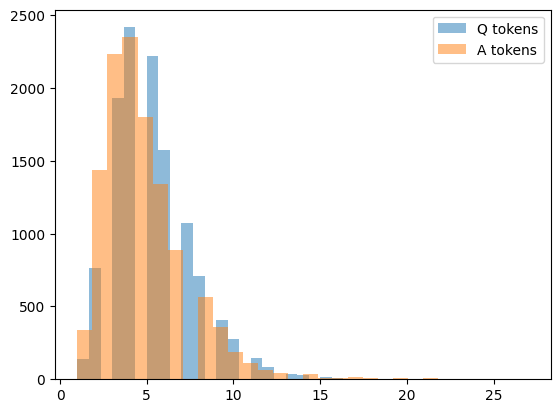

Q 토큰 최대: 21
A 토큰 최대: 27


In [30]:
# 전체 데이터 인코딩 후 길이 측정
q_token_lens = [len(sp_tokenizer.encode_as_ids(q)) for q in preprocessed_df['Q']]
a_token_lens = [len(sp_tokenizer.encode_as_ids(a)) for a in preprocessed_df['A']]

import matplotlib.pyplot as plt
plt.hist(q_token_lens, bins=30, alpha=0.5, label='Q tokens')
plt.hist(a_token_lens, bins=30, alpha=0.5, label='A tokens')
plt.legend()
plt.show()

print(f"Q 토큰 최대: {max(q_token_lens)}")
print(f"A 토큰 최대: {max(a_token_lens)}")

In [31]:
# BOS, EOS 토큰 고려하면 최소 30이상 지정 필요
# inference 단계에서 더 긴 글이 들어올 수 있으므로 64로 지정하고
# 편의상 인코더, 디코더 공용으로 사용
MAX_TOKEN_LEN = 64

## 1.4. 모델 학습을 위한 데이터셋 준비

### 1.4.1. 토큰화 및 정수 인덱싱

In [32]:
print(f"ID 0: {sp_tokenizer.IdToPiece(0)}")
print(f"ID 1: {sp_tokenizer.IdToPiece(1)}")
print(f"ID 2: {sp_tokenizer.IdToPiece(2)}")
print(f"ID 3: {sp_tokenizer.IdToPiece(3)}")

ID 0: <pad>
ID 1: <unk>
ID 2: <s>
ID 3: </s>


In [33]:
# 토큰화 및 정수 인덱싱
def tokenize_and_pad(sentences, tokenizer, max_token_len, mode='enc'):
    output = []
    for s in sentences:
        # 1. 순수 텍스트만 토큰화
        tokens = tokenizer.encode_as_ids(s)
        
        # 2. 모드에 따라 <s>, </s> 직접 삽입
        if mode == 'dec_input':
            tokens = [tokenizer.bos_id()] + tokens      # 반드시 2로 시작
        elif mode == 'dec_target':
            tokens = tokens + [tokenizer.eos_id()]      # 반드시 3으로 끝
        # enc 모드일 때는 아무것도 안 붙임
        
        # 3. Padding (max_token_len 길이에 맞춤)
        if len(tokens) < max_token_len:
            tokens += [tokenizer.pad_id()] * (max_token_len - len(tokens))
        else:
            tokens = tokens[:max_token_len]
            
        output.append(tokens)
    return output

In [34]:
preprocessed_df.head()

,Q,A
0,12시 땡!,하루가 또 가네요
1,1지망 학교 떨어졌어,위로해 드립니다
2,3박4일 놀러가고 싶다,여행은 언제나 좋죠
3,3박4일 정도 놀러가고 싶다,여행은 언제나 좋죠
4,PPL 심하네,눈살이 찌푸려지죠


In [35]:
# 토큰화 및 인덱싱 적용
enc_inputs = tokenize_and_pad(preprocessed_df['Q'], sp_tokenizer, MAX_TOKEN_LEN, mode='enc')
dec_inputs = tokenize_and_pad(preprocessed_df['A'], sp_tokenizer, MAX_TOKEN_LEN, mode='dec_input')
dec_targets = tokenize_and_pad(preprocessed_df['A'], sp_tokenizer, MAX_TOKEN_LEN, mode='dec_target')

In [71]:
# 결과 확인
print(enc_inputs[0][:32])
print(dec_inputs[0][:32])
print(dec_targets[0][:32])

[5499, 6964, 3171, 7069, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]
[2, 4432, 208, 5868, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]
[4432, 208, 5868, 3, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]


In [94]:
# numpy array로 변환
encoder_input_arr = np.array(enc_inputs) # 인코더의 입력
decoder_input_arr = np.array(dec_inputs) # 디코더의 입력
decoder_target_arr = np.array(dec_targets) # 디코더의 레이블

### 1.4.2. 학습 데이터와 테스트 데이터 분리

In [95]:
def convert_to_tensor(sequences):
    return [torch.tensor(seq, dtype=torch.long) for seq in sequences]

In [96]:
# index를 랜덤하게 섞음
indices = np.arange(encoder_input_arr.shape[0])
np.random.shuffle(indices)
print(indices[:10])

[ 6441  7788  5962  6417  2176  4572  4890 10663  4181  3453]


In [97]:
encoder_input_arr = encoder_input_arr[indices]
decoder_input_arr = decoder_input_arr[indices]
decoder_target_arr = decoder_target_arr[indices]

In [98]:
test_size = int(len(encoder_input_arr)*0.1)
val_size = test_size
train_size = len(encoder_input_arr) - val_size - test_size

print('train 데이터의 수 :', train_size)
print('validation 데이터의 수 :', val_size)
print('test 데이터의 수 :', test_size)
print(train_size+val_size+test_size, encoder_input_arr.shape)

train 데이터의 수 : 9459
validation 데이터의 수 : 1182
test 데이터의 수 : 1182
11823 (11823, 64)


In [100]:
encoder_input_train = torch.LongTensor((encoder_input_arr[:train_size]))
decoder_input_train = torch.LongTensor(decoder_input_arr[:train_size])
decoder_target_train = torch.LongTensor(decoder_target_arr[:train_size])

encoder_input_val = torch.LongTensor(encoder_input_arr[train_size : train_size+val_size])
decoder_input_val = torch.LongTensor(decoder_input_arr[train_size : train_size+val_size])
decoder_target_val = torch.LongTensor(decoder_target_arr[train_size : train_size+val_size])

encoder_input_test = torch.LongTensor(encoder_input_arr[train_size+val_size:])
decoder_input_test = torch.LongTensor(decoder_input_arr[train_size+val_size:])
decoder_target_test = torch.LongTensor(decoder_target_arr[train_size+val_size:])

In [101]:
print('train encoder input의 개수 :', len(encoder_input_train))
print('train decoder input의 개수 :', len(decoder_input_train))
print('train decoder target의 개수 :', len(decoder_target_train))

print('validation encoder input의 개수 :', len(encoder_input_val))
print('validation decoder input의 개수 :', len(decoder_input_val))
print('validation decoder target의 개수 :', len(decoder_target_val))

print('test encoder input의 개수 :', len(encoder_input_test))
print('test decoder input의 개수 :', len(decoder_input_test))
print('test decoder target의 개수 :', len(decoder_target_test))

train encoder input의 개수 : 9459
train decoder input의 개수 : 9459
train decoder target의 개수 : 9459
validation encoder input의 개수 : 1182
validation decoder input의 개수 : 1182
validation decoder target의 개수 : 1182
test encoder input의 개수 : 1182
test decoder input의 개수 : 1182
test decoder target의 개수 : 1182


# 2. 모델 정의

- Positional Encoding

In [102]:
class PositionalEncoding(nn.Module):
    def __init__(self, position, d_model):
        super(PositionalEncoding, self).__init__()
        self.d_model = d_model
        self.position = position

        self.pos_encoding = self._build_pos_encoding(position, d_model)

    def _get_angles(self, position, i, d_model):
        # i = 0, 1, ... 증가해도 2i = 0, 2i+1 = 1, ... 
        # 하나의 i를 2번 사용해야 하므로 i//2 해줘야 함
        return 1.0 / (10000.0 ** ((2.0 * (i // 2)) / d_model)) * position

    def _build_pos_encoding(self, position, d_model):
        pos = torch.arange(position, dtype=torch.float32).unsqueeze(1)
        i = torch.arange(d_model, dtype=torch.float32).unsqueeze(0)

        angle_rads = self._get_angles(pos, i, d_model)
        sines = torch.sin(angle_rads[:, 0::2])
        cosines = torch.cos(angle_rads[:, 1::2])

        pos_encoding = torch.zeros(position, d_model)
        pos_encoding[:, 0::2] = sines
        pos_encoding[:, 1::2] = cosines

        pos_encoding = pos_encoding.unsqueeze(0)  # shape: [1, position, d_model]
        return pos_encoding

    def forward(self, x):
        return x + self.pos_encoding[:, :x.size(1), :].to(x.device)

- scaled_dot_product_attention

In [103]:
# scaled_dot_product_attention 연산 수행 함수 정의
def scaled_dot_product_attention(Q, K, V, mask=None):

    # 1) Q와 K의 내적을 통해 score(유사도) 계산
    # K.transpose(-1, -2): (batch_size, heads, depth, seq_len)
    # matmul 결과 shape: (batch_size, heads, seq_len, seq_len)
    matmul_qk = torch.matmul(Q, K.transpose(-1, -2))

    # 2) depth에 따라 정규화
    depth = K.size(-1)  # depth = d_model / heads
    logits = matmul_qk / math.sqrt(depth)

    # 3) 마스크가 주어졌다면 -1e9(아주 작은 값)를 더해 소프트맥스에서 제외
    if mask is not None:                
        logits = logits + (mask * -1e9)

    # 4) 소프트맥스 계산해 attention weights 생성
    attn_weights = F.softmax(logits, dim=-1)

    # 5) attention weights와 value의 내적
    attn_values = torch.matmul(attn_weights, V)

    return attn_values, attn_weights

- Multi-head attention 블럭

In [104]:
class MultiHeadAttention(nn.Module):
    def __init__(self, d_model, num_heads, name="multi_head_attention"):
        super(MultiHeadAttention, self).__init__()
        self.num_heads = num_heads
        self.d_model = d_model

        # d_model은 num_heads로 나누어떨어져야 함
        assert d_model % num_heads == 0

        self.depth = d_model // num_heads

        # 파이토치에서 Dense는 nn.Linear로 대응
        self.query_dense = nn.Linear(d_model, d_model)
        self.key_dense = nn.Linear(d_model, d_model)
        self.value_dense = nn.Linear(d_model, d_model)

        self.out_dense = nn.Linear(d_model, d_model)

    def split_heads(self, x, batch_size):
        """
        x: (batch_size, seq_len, d_model)
        => (batch_size, num_heads, seq_len, depth) 형태로 변환
        """
        x = x.view(batch_size, -1, self.num_heads, self.depth)
        x = x.permute(0, 2, 1, 3)  # (batch_size, num_heads, seq_len, depth)
        return x

    def forward(self, query, key, value, mask=None):
        """
        query, key, value: (batch_size, seq_len, d_model)
        mask: (batch_size, 1, seq_len, seq_len) 등으로 broadcast 가능하도록 구성
        """
        batch_size = query.size(0)

        # Q, K, V에 각각 Linear 적용
        query = self.query_dense(query)
        key = self.key_dense(key)
        value = self.value_dense(value)

        # Head 분할
        query = self.split_heads(query, batch_size)
        key = self.split_heads(key, batch_size)
        value = self.split_heads(value, batch_size)

        # 스케일드 닷 프로덕트 어텐션
        scaled_attention, _ = scaled_dot_product_attention(query, key, value, mask)

        # (batch_size, num_heads, seq_len, depth) -> (batch_size, seq_len, num_heads, depth)
        scaled_attention = scaled_attention.permute(0, 2, 1, 3).contiguous()

        # 다시 (batch_size, seq_len, d_model)로 합치기
        concat_attention = scaled_attention.view(batch_size, -1, self.d_model)

        # 최종 Dense
        output = self.out_dense(concat_attention)
        return output


- 마스킹

In [105]:
# 패딩 마스크
def create_padding_mask(x):
    # x == 0 위치를 찾아 float형 1로 변환
    mask = (x == 0).float()
    # (batch_size, seq_len) -> (batch_size, 1, 1, seq_len)
    mask = mask.unsqueeze(1).unsqueeze(2)
    return mask

In [106]:
# 디코더에서 사용할 Look-ahead 마스크
def create_look_ahead_mask(x):
    seq_len = x.size(1)

    # (seq_len, seq_len) 크기의 lower triangle 행렬(tril) 생성 후 1에서 빼서
    # 상삼각이 1, 하삼각(자기 자신 포함)이 0이 되도록 설정
    # => 미래 토큰(자신 인덱스보다 큰 위치) 마스킹
    look_ahead_mask = 1 - torch.tril(torch.ones((seq_len, seq_len)))

    # 패딩 마스크 생성 (shape: (batch_size, 1, 1, seq_len))
    padding_mask = create_padding_mask(x)

    # look_ahead_mask: (seq_len, seq_len) -> (1, seq_len, seq_len)
    look_ahead_mask = look_ahead_mask.unsqueeze(0)
    # -> (1, seq_len, seq_len) -> (1, 1, seq_len, seq_len)
    look_ahead_mask = look_ahead_mask.unsqueeze(1)
    look_ahead_mask = look_ahead_mask.to(x.device)

    # look-ahead 마스크와 패딩 마스크를 합성 (둘 중 하나라도 1이면 마스킹)
    # 최종 shape은 브로드캐스팅으로 (batch_size, 1, seq_len, seq_len)
    combined_mask = torch.max(look_ahead_mask, padding_mask)
    return combined_mask

- Encoder

In [107]:
# 단일 encoder 블럭
class EncoderLayer(nn.Module):
    def __init__(self, d_model, num_heads, ff_dim, dropout=0.1):
        super(EncoderLayer, self).__init__()
        self.mha = MultiHeadAttention(d_model, num_heads)  # 이전에 구현한 MHA
        self.dropout1 = nn.Dropout(dropout)
        self.norm1 = nn.LayerNorm(d_model, eps=1e-6)

        # 피드포워드 부분 (Dense -> ReLU -> Dense)
        self.ffn = nn.Sequential(
            nn.Linear(d_model, ff_dim),
            nn.ReLU(),
            nn.Linear(ff_dim, d_model)
        )
        self.dropout2 = nn.Dropout(dropout)
        self.norm2 = nn.LayerNorm(d_model, eps=1e-6)

    def forward(self, x, mask=None):
        # (1) 멀티 헤드 어텐션 (셀프 어텐션)
        attn_output = self.mha(x, x, x, mask)  # (batch_size, seq_len, d_model)
        attn_output = self.dropout1(attn_output)
        out1 = self.norm1(x + attn_output)     # 잔차 연결 + LayerNorm

        # (2) 피드포워드 신경망
        ffn_output = self.ffn(out1)            # (batch_size, seq_len, d_model)
        ffn_output = self.dropout2(ffn_output)
        out2 = self.norm2(out1 + ffn_output)   # 잔차 연결 + LayerNorm

        return out2


In [108]:
# 인코더 층
class Encoder(nn.Module):
    def __init__(self, vocab_size, max_token_len, num_layers, ff_dim, d_model, num_heads, dropout=0.1):
        super(Encoder, self).__init__()
        self.d_model = d_model

        # (1) 임베딩 레이어
        self.embedding = nn.Embedding(vocab_size, d_model)

        # (2) 포지셔널 인코딩
        self.pos_encoding = PositionalEncoding(position=max_token_len, d_model=d_model)

        self.dropout = nn.Dropout(dropout)

        # (3) EncoderLayer 쌓기
        self.enc_layers = nn.ModuleList([
            EncoderLayer(d_model, num_heads, ff_dim, dropout)
            for _ in range(num_layers)
        ])

    def forward(self, x, mask=None):
        # (1) 임베딩 & sqrt(d_model)로 스케일링
        x = self.embedding(x) * math.sqrt(self.d_model)

        # (2) 포지셔널 인코딩 적용 + 드롭아웃
        x = self.pos_encoding(x)  # shape: (batch_size, seq_len, d_model)
        x = self.dropout(x)

        # (3) num_layers만큼 쌓아올린 EncoderLayer 통과
        for layer in self.enc_layers:
            x = layer(x, mask)

        return x

- Decoder

In [109]:
# 단일 디코더 블럭
class DecoderLayer(nn.Module):
    def __init__(self, d_model, num_heads, ff_dim, dropout=0.1):
        super(DecoderLayer, self).__init__()

        # 첫 번째 서브 레이어 (디코더 내부 셀프 어텐션)
        self.self_mha = MultiHeadAttention(d_model, num_heads)
        self.norm1 = nn.LayerNorm(d_model, eps=1e-6)

        # 두 번째 서브 레이어 (인코더-디코더 어텐션)
        self.encdec_mha = MultiHeadAttention(d_model, num_heads)
        self.norm2 = nn.LayerNorm(d_model, eps=1e-6)

        # 세 번째 서브 레이어 (피드포워드 네트워크)
        self.ffn = nn.Sequential(
            nn.Linear(d_model, ff_dim),  # Dense(units=ff_dim)
            nn.ReLU(),                   # activation='relu'
            nn.Linear(ff_dim, d_model)   # Dense(units=d_model)
        )
        self.norm3 = nn.LayerNorm(d_model, eps=1e-6)

        # 드롭아웃
        self.dropout1 = nn.Dropout(dropout)
        self.dropout2 = nn.Dropout(dropout)
        self.dropout3 = nn.Dropout(dropout)

    def forward(self, x, enc_outputs, look_ahead_mask=None, padding_mask=None):
        # 1) 셀프 어텐션 (디코더 내부)
        self_attn_out = self.self_mha(x, x, x, mask=look_ahead_mask)
        self_attn_out = self.dropout1(self_attn_out)
        out1 = self.norm1(x + self_attn_out)  # 잔차 연결 + LayerNorm

        # 2) 인코더-디코더 어텐션
        encdec_attn_out = self.encdec_mha(out1, enc_outputs, enc_outputs, mask=padding_mask)
        encdec_attn_out = self.dropout2(encdec_attn_out)
        out2 = self.norm2(out1 + encdec_attn_out)  # 잔차 연결 + LayerNorm

        # 3) 피드포워드 (Dense -> ReLU -> Dense)
        ffn_out = self.ffn(out2)
        ffn_out = self.dropout3(ffn_out)
        out3 = self.norm3(out2 + ffn_out)  # 잔차 연결 + LayerNorm

        return out3

In [110]:
class Decoder(nn.Module):
    def __init__(self, vocab_size, max_token_len, num_layers, ff_dim, d_model, num_heads, dropout=0.1):
        super(Decoder, self).__init__()
        self.d_model = d_model

        # (1) 임베딩 레이어
        self.embedding = nn.Embedding(vocab_size, d_model)

        # (2) 포지셔널 인코딩
        # 실제 학습 시에는 최대 시퀀스 길이에 맞추어 쓰기도 함
        self.pos_encoding = PositionalEncoding(position=max_token_len, d_model=d_model)

        self.dropout = nn.Dropout(dropout)

        # (3) DecoderLayer 쌓기
        self.dec_layers = nn.ModuleList([
            DecoderLayer(d_model, num_heads, ff_dim, dropout)
            for _ in range(num_layers)
        ])

    def forward(self, x, enc_outputs, look_ahead_mask=None, padding_mask=None):
        # (1) 임베딩 + sqrt(d_model)로 스케일링
        x = self.embedding(x) * math.sqrt(self.d_model)

        # (2) 포지셔널 인코딩 + 드롭아웃
        x = self.pos_encoding(x)    # (batch_size, tgt_seq_len, d_model)
        x = self.dropout(x)

        # (3) num_layers만큼 쌓인 DecoderLayer 통과
        for layer in self.dec_layers:
            x = layer(x, enc_outputs, look_ahead_mask, padding_mask)

        return x

- Transformer

In [122]:
class Transformer(nn.Module):
    def __init__(self,
                 vocab_size,
                 max_token_len,# 최대 토큰 길이
                 num_layers,      # 인코더/디코더 층 수
                 units,           # feed-forward 네트워크의 중간 차원(ff_dim)
                 d_model,         # 임베딩 및 내부 표현 차원
                 num_heads,       # 멀티헤드 어텐션의 헤드 수
                 dropout=0.1):
        super(Transformer, self).__init__()

        # 인코더
        self.encoder = Encoder(
            vocab_size=vocab_size,
            max_token_len=max_token_len,
            num_layers=num_layers,
            ff_dim=units,
            d_model=d_model,
            num_heads=num_heads,
            dropout=dropout
        )

        # 디코더
        self.decoder = Decoder(
            vocab_size=vocab_size,
            max_token_len=max_token_len,
            num_layers=num_layers,
            ff_dim=units,
            d_model=d_model,
            num_heads=num_heads,
            dropout=dropout
        )

        # 최종 출력층: (d_model) -> (vocab_size)
        self.final_linear = nn.Linear(d_model, vocab_size)

    def forward(self, inputs, dec_inputs):
        # 1) 인코더 패딩 마스크 생성
        enc_padding_mask = create_padding_mask(inputs)     # shape (batch_size, 1, 1, src_seq_len)

        # 2) 디코더 look-ahead + 패딩 마스크
        look_ahead_mask = create_look_ahead_mask(dec_inputs)  # shape (batch_size, 1, tgt_seq_len, tgt_seq_len)

        # 3) 디코더에서 인코더 출력 쪽을 마스킹할 때 쓸 패딩 마스크
        dec_padding_mask = create_padding_mask(inputs)        # shape (batch_size, 1, 1, src_seq_len)

        # 4) 인코더 수행
        enc_outputs = self.encoder(
            x=inputs,
            mask=enc_padding_mask
        )  # shape: (batch_size, src_seq_len, d_model)

        # 5) 디코더 수행
        dec_outputs = self.decoder(
            x=dec_inputs,           # (batch_size, tgt_seq_len)
            enc_outputs=enc_outputs,# (batch_size, src_seq_len, d_model)
            look_ahead_mask=look_ahead_mask,
            padding_mask=dec_padding_mask
        )  # shape: (batch_size, tgt_seq_len, d_model)

        # 6) 최종 Dense (vocab_size)
        logits = self.final_linear(dec_outputs)  # (batch_size, tgt_seq_len, vocab_size)
        return logits

# 3. 모델 학습

In [392]:
BATCH_SIZE = 128
EPOCHS = 30
# LR = 0.001
# PATIENCE = 2

In [393]:
# DataLoader 설정
train_dataset = TensorDataset(encoder_input_train, decoder_input_train, decoder_target_train)
valid_dataset = TensorDataset(encoder_input_val, decoder_input_val, decoder_target_val)
test_dataset = TensorDataset(encoder_input_test, decoder_input_test, decoder_target_test)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=0)
valid_loader = DataLoader(valid_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=0)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=0)

- 하이퍼 파라미터 설정

In [394]:
NUM_LAYERS = 3     # 인코더/디코더 층 수
D_MODEL = 256      # 임베딩 및 내부 표현 차원
NUM_HEADS = 8      # 멀티헤드 어텐션에서의 헤드 수
UNITS = 512        # 피드포워드 신경망의 은닉 차원
DROPOUT = 0.3      # 드롭아웃 비율
# VOCAB_SIZE = 8000 # 단어 집합 크기(예시)

In [395]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(device)

cuda


In [396]:
# loss function -> padding 값에 대해서는 loss 계산 방지
loss_function = nn.CrossEntropyLoss(ignore_index=sp_tokenizer.pad_id())

- Learning Rate customizing

In [397]:
def get_lr_lambda(d_model, warmup_steps=400):
    d_model = float(d_model)
    def lr_lambda(step):
        # step은 0부터 시작하므로 +1로 보정
        step = step + 1
        return (d_model ** -0.5) * min(step ** -0.5, step * (warmup_steps ** -1.5))
    return lr_lambda

In [398]:
def accuracy_function(y_pred, y_true, pad_id=0):
    """
    y_pred: (batch_size, seq_len, vocab_size)
    y_true: (batch_size, seq_len)
    """
    preds = y_pred.argmax(dim=-1)  # (batch_size, seq_len)
    mask = (y_true != pad_id)
    correct = (preds == y_true) & mask
    acc = correct.float().sum() / mask.float().sum()
    return acc

In [399]:
model = Transformer(
    vocab_size=VOCAB_SIZE,
    max_token_len=MAX_TOKEN_LEN,
    num_layers=NUM_LAYERS,
    units=UNITS,
    d_model=D_MODEL,
    num_heads=NUM_HEADS,
    dropout=DROPOUT
).to(device)

model

Transformer(
  (encoder): Encoder(
    (embedding): Embedding(8000, 256)
    (pos_encoding): PositionalEncoding()
    (dropout): Dropout(p=0.3, inplace=False)
    (enc_layers): ModuleList(
      (0-2): 3 x EncoderLayer(
        (mha): MultiHeadAttention(
          (query_dense): Linear(in_features=256, out_features=256, bias=True)
          (key_dense): Linear(in_features=256, out_features=256, bias=True)
          (value_dense): Linear(in_features=256, out_features=256, bias=True)
          (out_dense): Linear(in_features=256, out_features=256, bias=True)
        )
        (dropout1): Dropout(p=0.3, inplace=False)
        (norm1): LayerNorm((256,), eps=1e-06, elementwise_affine=True)
        (ffn): Sequential(
          (0): Linear(in_features=256, out_features=512, bias=True)
          (1): ReLU()
          (2): Linear(in_features=512, out_features=256, bias=True)
        )
        (dropout2): Dropout(p=0.3, inplace=False)
        (norm2): LayerNorm((256,), eps=1e-06, elementwise_aff

In [400]:
# Optimizer 정의
optimizer = optim.Adam(model.parameters(), lr=1.0, betas=(0.9, 0.98), eps=1e-9)

# Scheduler 정의
scheduler = lr_scheduler.LambdaLR(optimizer, lr_lambda=get_lr_lambda(D_MODEL, warmup_steps=400))

- 모델 학습

In [401]:
def train_step(model, batch, optimizer, loss_function, device):
    model.train()
    enc_input, dec_input, target = [x.to(device) for x in batch]

    optimizer.zero_grad()

    # 모델 포워드 패스
    logits = model(enc_input, dec_input)  # (batch_size, seq_len, vocab_size)

    # Loss 계산 (패딩 토큰 무시)
    loss = loss_function(logits.permute(0, 2, 1), target)  # (batch_size, vocab_size, seq_len) 필요

    # Backpropagation
    loss.backward()
    optimizer.step()

    return loss.item(), accuracy_function(logits, target, pad_id=sp_tokenizer.pad_id())

In [402]:
def validate(model, dataloader, loss_function, device):
    model.eval() # 평가 모드 (Dropout, Batch Norm 비활성화)
    total_loss, total_acc = 0, 0
    
    with torch.no_grad(): # 그래디언트 계산 중지 (메모리 절약)
        for batch in dataloader:
            enc_input, dec_input, target = [x.to(device) for x in batch]
            logits = model(enc_input, dec_input)
            
            loss = loss_function(logits.permute(0, 2, 1), target)
            acc = accuracy_function(logits, target, pad_id=sp_tokenizer.pad_id())
            
            total_loss += loss.item()
            total_acc += acc
            
    return total_loss / len(dataloader), total_acc / len(dataloader)

In [403]:
def train(model, train_loader, val_loader, optimizer, loss_function, scheduler, num_epochs, device):
    model.to(device)
    history = {'train_loss': [], 'val_loss': [], 'train_acc': [], 'val_acc': []}
    best_val_loss = float('inf')

    for epoch in range(num_epochs):
        # --- [Train Step] ---
        total_loss, total_acc = 0, 0
        model.train()
        for step, batch in enumerate(train_loader):
            loss, acc = train_step(model, batch, optimizer, loss_function, device)
            total_loss += loss
            total_acc += acc
            
            if step % 100 == 0:
                print(f"[Epoch {epoch+1}, Step {step}] Train Loss: {loss:.4f}, Acc: {acc:.4f}")
            
            scheduler.step()

        avg_train_loss = total_loss / len(train_loader)
        avg_train_acc = total_acc / len(train_loader)

        # --- [Validation Step] ---
        avg_val_loss, avg_val_acc = validate(model, val_loader, loss_function, device)
        
        # --- [History Logging & Model Save] ---
        history['train_loss'].append(avg_train_loss)
        history['val_loss'].append(avg_val_loss)
        history['train_acc'].append(avg_train_acc.item())
        history['val_acc'].append(avg_val_acc.item())

        print(f"\n== Epoch {epoch+1} ==\nTrain Loss: {avg_train_loss:.4f}, Val Loss: {avg_val_loss:.4f}")
        print(f"Train Acc: {avg_train_acc:.4f}, Val Acc: {avg_val_acc:.4f}\n")

        # Best 모델 저장 (추론 시 사용)
        if avg_val_loss < best_val_loss:
            best_val_loss = avg_val_loss
            torch.save({"model": model.state_dict(),
                        "epoch": epoch+1,
                        "optimizer": optimizer}, MODEL_PATH + "best_chatbot.pt")
            # torch.save(model.state_dict(), 'best_transformer_model.pth')
            print("--- Best Model Saved! ---\n")

    return history

In [404]:
# 1. 학습 실행
history = train(model, train_loader, valid_loader, optimizer, loss_function, scheduler, num_epochs=EPOCHS, device=device)


[Epoch 1, Step 0] Train Loss: 9.1926, Acc: 0.0000

== Epoch 1 ==
Train Loss: 7.6881, Val Loss: 6.9576
Train Acc: 0.1502, Val Acc: 0.1713

--- Best Model Saved! ---

[Epoch 2, Step 0] Train Loss: 6.9141, Acc: 0.1702

== Epoch 2 ==
Train Loss: 6.6911, Val Loss: 6.4401
Train Acc: 0.1796, Val Acc: 0.1895

--- Best Model Saved! ---

[Epoch 3, Step 0] Train Loss: 6.4112, Acc: 0.1928

== Epoch 3 ==
Train Loss: 6.0969, Val Loss: 5.9483
Train Acc: 0.2022, Val Acc: 0.2193

--- Best Model Saved! ---

[Epoch 4, Step 0] Train Loss: 5.3702, Acc: 0.2346

== Epoch 4 ==
Train Loss: 5.4019, Val Loss: 5.5809
Train Acc: 0.2333, Val Acc: 0.2441

--- Best Model Saved! ---

[Epoch 5, Step 0] Train Loss: 4.7541, Acc: 0.2648

== Epoch 5 ==
Train Loss: 4.7176, Val Loss: 5.2755
Train Acc: 0.2786, Val Acc: 0.2712

--- Best Model Saved! ---

[Epoch 6, Step 0] Train Loss: 4.0969, Acc: 0.3135

== Epoch 6 ==
Train Loss: 4.1808, Val Loss: 5.1658
Train Acc: 0.3209, Val Acc: 0.2960

--- Best Model Saved! ---

[Epoch 7, 

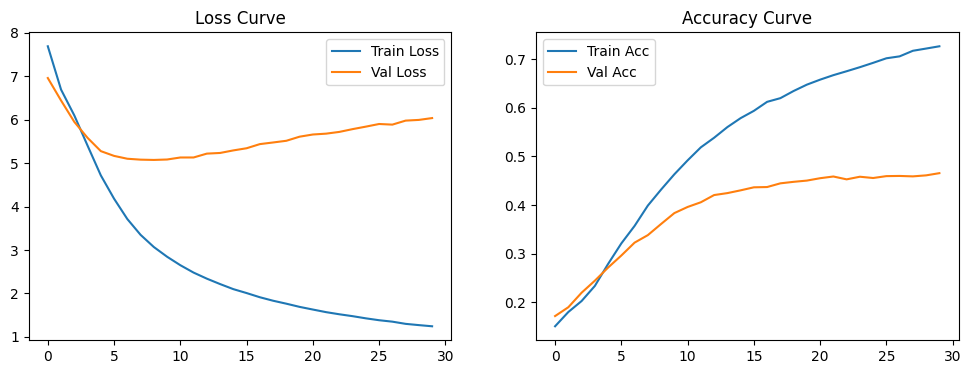

In [405]:
# 결과 그래프
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(history['train_loss'], label='Train Loss')
plt.plot(history['val_loss'], label='Val Loss')
plt.title('Loss Curve')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history['train_acc'], label='Train Acc')
plt.plot(history['val_acc'], label='Val Acc')
plt.title('Accuracy Curve')
plt.legend()

plt.show()

# 4. 챗봇 테스트

In [406]:
def decoder_inference(model, sentence, tokenizer, max_token_len, device='cpu'):
    START_TOKEN = tokenizer.bos_id()
    END_TOKEN = tokenizer.eos_id()
    MAX_LENGTH = max_token_len

    # 전처리
    sentence = preprocess_sentence(sentence)

    # 인코더 입력: [START] + 인코딩 + [END]
    enc_input_ids = [START_TOKEN] + tokenizer.encode(sentence) + [END_TOKEN]
    # 차원 확장: (batch_size=1, seq_len)
    enc_input = torch.tensor([enc_input_ids], dtype=torch.long, device=device)

    # 디코더 입력(dec_input)을 START_TOKEN만 포함한 상태로 시작
    dec_input = torch.tensor([[START_TOKEN]], dtype=torch.long, device=device)

    model.eval()  # 모델 평가 모드
    with torch.no_grad():
        for i in range(MAX_LENGTH):
            # 모델 forward: (enc_input, dec_input) -> (batch_size=1, seq_len, vocab_size)
            logits = model(enc_input, dec_input)

            # 마지막 타임스텝의 예측만 추출: shape (1, 1, vocab_size)
            # logits[:, -1, :] -> (1, vocab_size)
            last_step_logits = logits[:, -1, :]

            # argmax로 가장 높은 확률의 토큰 선택
            predicted_id = torch.argmax(last_step_logits, dim=-1)  # shape: (1,)

            # 종료 토큰이면 중단
            if predicted_id.item() == END_TOKEN:
                break

            # 디코더 입력(dec_input)에 예측 토큰을 이어붙임
            predicted_id = predicted_id.unsqueeze(0)  # shape (1,1)
            dec_input = torch.cat([dec_input, predicted_id], dim=1)

    # 최종 시퀀스: dec_input: (1, seq_len)에서 (seq_len,)로
    output_sequence = dec_input.squeeze(0).tolist()  # e.g. [START_TOKEN, ..., 토큰들...]

    return output_sequence

In [407]:
def sentence_generation(model, sentence, tokenizer, max_token_len=MAX_TOKEN_LEN, device='cpu'):
    # 디코더 인퍼런스 -> 예측된 토큰 시퀀스
    output_seq = decoder_inference(model, sentence, tokenizer, max_token_len, device=device)

    # 토크나이저로 디코딩 (패딩, START/END 토큰 등은 제외하거나 처리)
    # 여기서는 단순히 tokenizer.decode() 직접 호출
    predicted_sentence = tokenizer.decode(
        [token for token in output_seq if token < tokenizer.GetPieceSize()]
    )

    print("입력 :", sentence)
    print("출력 :", predicted_sentence)
    return predicted_sentence

In [408]:
loaded_model = Transformer(
    vocab_size=VOCAB_SIZE,
    max_token_len=MAX_TOKEN_LEN,
    num_layers=NUM_LAYERS,
    units=UNITS,
    d_model=D_MODEL,
    num_heads=NUM_HEADS,
    dropout=DROPOUT).to(device)

model_path = MODEL_PATH + "best_chatbot.pt"
ckpt = torch.load(model_path, map_location=device, weights_only=False)
# ckpt = torch.load('best_transformer_model.pth', map_location=device, weights_only=False)
loaded_model.load_state_dict(ckpt['model'])

<All keys matched successfully>

In [410]:
ckpt['epoch']

9

In [411]:
sentence = '12시 땡!'
answer = sentence_generation(loaded_model, sentence, sp_tokenizer, max_token_len=MAX_TOKEN_LEN, device=device)

입력 : 12시 땡!
출력 : 좋은 결과 있을 거예요


In [412]:
sentence = '좋은 아침입니다'
answer = sentence_generation(loaded_model, sentence, sp_tokenizer, max_token_len=MAX_TOKEN_LEN, device=device)

입력 : 좋은 아침입니다
출력 : 좋은 생각이에요


In [413]:
sentence = '날씨가 더워졌어'
answer = sentence_generation(loaded_model, sentence, sp_tokenizer, max_token_len=MAX_TOKEN_LEN, device=device)

입력 : 날씨가 더워졌어
출력 : 좋은 결과 있을 거예요


In [414]:
sentence = '기분이 좋아지려면 뭘 해야 할까?'
answer = sentence_generation(loaded_model, sentence, sp_tokenizer, max_token_len=MAX_TOKEN_LEN, device=device)

입력 : 기분이 좋아지려면 뭘 해야 할까?
출력 : 그 누구보다 잘해줘서요


# 회고

- 트랜스포머 모델을 구성하는 각 모듈에 대한 이해를 철저히 해야겠다.
- 모델 정의하고 데이터 집어넣는 단순한 문제가 아니라, 데이터를 전처리하는 순간부터 신경써줘야 할 부분들이 적지 않음을 다시 한 번 체감했다.
- 처음에 loss가 잘 내려가지 않았는데, 제미나이로 검색해보니 LambdaLR로 논문 수식을 그대로 구현할 때는 **lr=1.0**로 지정해야 한다는 것을 알게 되었다. 그대로 적용 후 눈에 띄게 학습이 잘 되었다.
- 그러나 overfitting 발생으로 성능이 썩 좋지는 않아서 추가적인 개선 작업을 시도해야겠다.